<a href="https://colab.research.google.com/github/aniruddhagalgali/bprim_ai/blob/main/20260816_PrincipalComponentAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
###
### Principal Component Analysis
### Dimension reduction technique
###

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [11]:
customers = pd.read_csv("/content/customer_rfm.csv")
customers.head()

,recency,frequency,monetary
0,24.0,19.0,4602.0
1,17.0,30.0,6544.0
2,20.0,27.0,5760.0
3,26.0,17.0,5070.0
4,24.0,32.0,4020.0


In [23]:
customers_scaled = StandardScaler().fit_transform(customers)
pca = PCA()
pca.fit(customers_scaled)

PCA()

### Determining the Number of Principal Components

To decide how many principal components to keep, we can examine the `explained_variance_ratio_` attribute of the PCA object. This attribute tells us the proportion of variance explained by each principal component. We can plot the cumulative explained variance to see how many components are needed to explain a significant portion of the total variance.

[0.88543516 0.08604199 0.02852286]


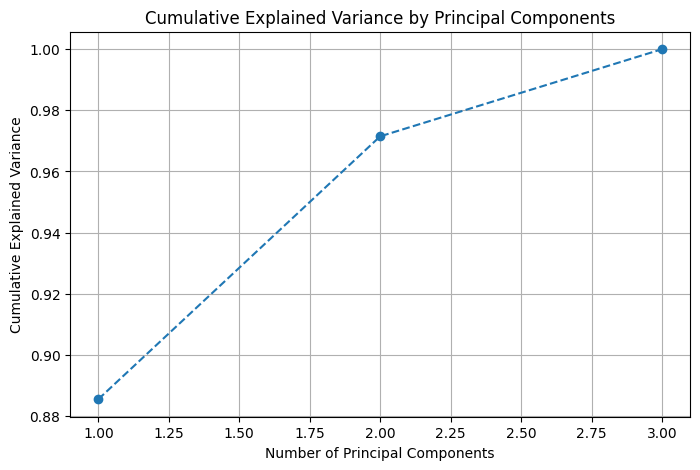

In [25]:
explained_variance_ratio = pca.explained_variance_ratio_
print(explained_variance_ratio)
cumulative_explained_variance = explained_variance_ratio.cumsum()

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker="o", linestyle="--")
plt.title("Cumulative Explained Variance by Principal Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

Text(0.5, 1.0, 'Explained Variance Ratio by Principal Components')

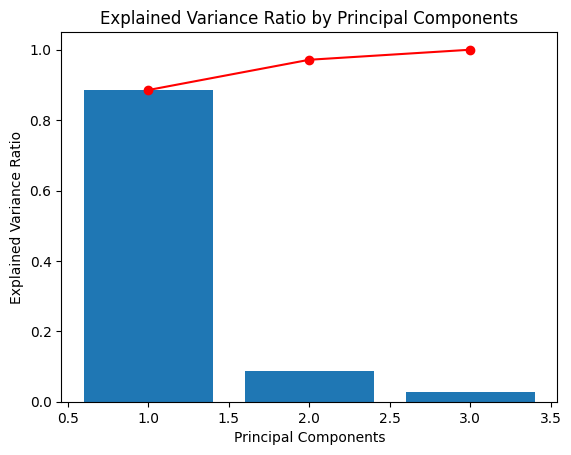

In [31]:
plt.bar([1,2,3],explained_variance_ratio)
plt.plot([1,2,3],cumulative_explained_variance, marker="o", color="red")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance Ratio by Principal Components")

From the plot, you can choose the number of components that capture a high percentage of the variance (e.g., 90-95%). For simplicity, I will proceed with 2 principal components for visualization purposes.

In [32]:
loadings = pd.DataFrame(pca.components_.T, columns=["PC1", "PC2", "PC3"], index=customers.columns)
display(loadings)

,PC1,PC2,PC3
recency,-0.556768,0.825282,0.094442
frequency,0.583867,0.469679,-0.662194
monetary,0.590854,0.313547,0.743357


In [19]:
pca = PCA(n_components=2) # Choosing 2 components for easy visualization
pca_components = pca.fit_transform(customers_scaled)

pca_df = pd.DataFrame(data=pca_components, columns=["PC1", "PC2"])
display(pca_df.head())

,PC1,PC2
0,1.534520,-0.041062
1,2.779678,0.647959
2,2.353684,0.435312
3,1.546181,-0.025931
4,2.067859,0.435521


### K-Means Clustering

Now, let"s apply a simple K-Means clustering algorithm to the PCA-transformed data. K-Means is an unsupervised learning algorithm that partitions data into `k` clusters, where each data point belongs to the cluster with the nearest mean.

In [20]:
from sklearn.cluster import KMeans

# Let"s assume we want to find 3 clusters as an example
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(pca_df)

pca_df["Cluster"] = clusters
display(pca_df.head())

,PC1,PC2,Cluster
0,1.534520,-0.041062,2
1,2.779678,0.647959,2
2,2.353684,0.435312,2
3,1.546181,-0.025931,2
4,2.067859,0.435521,2


### Visualizing the Clusters

Finally, we can visualize the clusters using the first two principal components. This will help us see how well the data points are separated into different groups by the K-Means algorithm.